--- Model Evaluation ---
Mean Absolute Error (MAE):  $1970.18
Root Mean Squared Error (RMSE): $2716.46


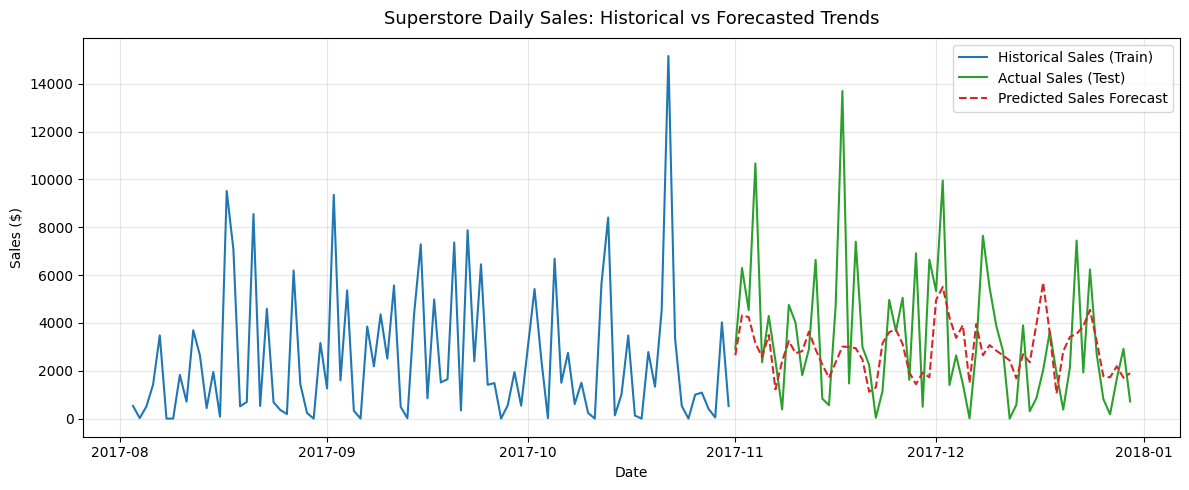

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -------------------------------------------------------------
# 1. Load and Aggregate Superstore Data
# -------------------------------------------------------------
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

# Convert Order Date to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Aggregate total sales per day
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
daily_sales = daily_sales.rename(columns={'Order Date': 'Date', 'Sales': 'Daily_Sales'})

# Sort and fill missing calendar days with 0 sales for a continuous timeline
daily_sales = daily_sales.sort_values('Date').set_index('Date').asfreq('D', fill_value=0).reset_index()

# -------------------------------------------------------------
# 2. Feature Engineering (Temporal & Lagged Features)
# -------------------------------------------------------------
daily_sales['Day'] = daily_sales['Date'].dt.day
daily_sales['Month'] = daily_sales['Date'].dt.month
daily_sales['Year'] = daily_sales['Date'].dt.year
daily_sales['DayOfWeek'] = daily_sales['Date'].dt.dayofweek
daily_sales['Quarter'] = daily_sales['Date'].dt.quarter

# Historical signals: yesterday's sales, last week's sales, 7-day moving average
daily_sales['Lag_1'] = daily_sales['Daily_Sales'].shift(1)
daily_sales['Lag_7'] = daily_sales['Daily_Sales'].shift(7)
daily_sales['Rolling_Mean_7'] = daily_sales['Daily_Sales'].shift(1).rolling(window=7).mean()

# Drop initial empty lag rows
daily_sales = daily_sales.dropna().reset_index(drop=True)

# -------------------------------------------------------------
# 3. Chronological Train-Test Split
# -------------------------------------------------------------
features = ['Day', 'Month', 'Year', 'DayOfWeek', 'Quarter', 'Lag_1', 'Lag_7', 'Rolling_Mean_7']
X = daily_sales[features]
y = daily_sales['Daily_Sales']

# Reserve the final 60 days to evaluate predictions
split_index = len(daily_sales) - 60
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
test_dates = daily_sales['Date'].iloc[split_index:]

# -------------------------------------------------------------
# 4. Model Training & Evaluation
# -------------------------------------------------------------
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE):  ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

# -------------------------------------------------------------
# 5. Visualization
# -------------------------------------------------------------
plt.figure(figsize=(12, 5))

# Plot the last 90 days of training data alongside the 60-day forecast for visual readability
recent_train = daily_sales.iloc[split_index - 90:split_index]
plt.plot(recent_train['Date'], recent_train['Daily_Sales'], label='Historical Sales (Train)', color='#1f77b4')
plt.plot(test_dates, y_test, label='Actual Sales (Test)', color='#2ca02c')
plt.plot(test_dates, predictions, label='Predicted Sales Forecast', color='#d62728', linestyle='--')

plt.title('Superstore Daily Sales: Historical vs Forecasted Trends', fontsize=13, pad=10)
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('superstore_forecast_plot.png')
plt.show()